# seedverify · E4 — hybrid retrieval: sparse ∪ dense seed → LLM reader

[E3](seedverify_alert_demo.ipynb) scanned real SEC filings for an analyst alert with a
**lexical** char-trigram seed in front of an **LLM verify**, and found its limit: the LLM
accepts *paraphrases* ("deficiencies in our financial reporting controls") that share no
trigrams with the alert, so the lexical seed cannot surface them. That recall ceiling is the
boundary between *lexical* and *semantic* retrieval.

E4 crosses it by adding the other arm of a modern retrieval stack — a **dense embedding
seed** (a local `embeddinggemma` model, cosine over cached vectors) — and **fusing** it with
the trigram seed. The result is exactly the **RAG** shape: a cheap retriever (now
sparse **and** dense) proposing candidates, an expensive reader (the LLM) judging only those.

**That the architecture is industry-standard is a feature, not a flaw.** BM25 + dense
bi-encoders + reciprocal-rank fusion + cross-encoder/LLM rerankers are the proven backbone of
retrieval. What this lab adds is *legibility*: a single cost law that says when the expensive
reader is worth gating, a candidate **budget that is an explicit recall dial**, and a seed
that **diagnoses its own limit** — telling you precisely when lexical retrieval is exhausted
and the dense arm must take over. The payoff in a search context is large: **full coverage of
the LLM's judgements at a fraction of the LLM calls**, on a laptop, fully local.

This notebook establishes three things, each measured on real SEC data:
1. the **dense arm recovers** the semantic matches the lexical seed is blind to;
2. **naive equal-weight fusion can hurt** (it dilutes a dominant arm);
3. **weighting the dense arm** gives a fusion that tracks the better arm in every regime.

In [1]:
import subprocess, io, os, re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

WORK = os.getcwd(); BIN = "./target/release/seedverify"
SEC_PATH = "/var/home/fraser/machine_learning/COBOL/main_menu/sec_riskfactors/data/SEC10K.DAT"
MODEL, EMBED_MODEL = "gemma4:e2b", "embeddinggemma"
ALERT_LEX = "material weakness in internal control over financial reporting"          # lexically anchored
ALERT_SEM = "the company depends on a small number of large customers for much of its revenue"  # semantic

r = subprocess.run(["cargo","build","--release"], capture_output=True, text=True)
print(r.stderr.strip().splitlines()[-1] if r.stderr else ""); assert r.returncode==0 and os.path.exists(BIN)

def ollama_up():
    try:
        r = subprocess.run(["curl","-s","--max-time","3","http://localhost:11434/api/tags"], capture_output=True, text=True)
        return r.returncode==0 and EMBED_MODEL.split(":")[0] in r.stdout and MODEL.split(":")[0] in r.stdout
    except Exception: return False
LIVE = ollama_up() and os.path.exists(SEC_PATH)
print("running the real (cached) pipeline" if LIVE else "using recorded numbers", "| ollama:", ollama_up())

def run_hybrid(alert):
    a = [BIN,"bench","--kind","hybrid","--backend","ollama","--model",MODEL,"--embed-model",EMBED_MODEL,
         "--sec",SEC_PATH,"--chunks","200","--alert",alert]
    r = subprocess.run(a, capture_output=True, text=True)
    if "budget," not in r.stdout: return None, r.stderr
    return pd.read_csv(io.StringIO(r.stdout)), r.stderr

# Recorded fallback (this machine, 200 SEC passages, gemma4:e2b verify, embeddinggemma seed)
REC = {
 ALERT_LEX: pd.DataFrame([
    dict(budget=10,lexical=77.8,embedding=88.9,rrf_equal=100,rrf_embweighted=100,n_matches=9),
    dict(budget=20,lexical=88.9,embedding=100,rrf_equal=100,rrf_embweighted=100,n_matches=9),
    dict(budget=40,lexical=100,embedding=100,rrf_equal=100,rrf_embweighted=100,n_matches=9),
    dict(budget=80,lexical=100,embedding=100,rrf_equal=100,rrf_embweighted=100,n_matches=9),
    dict(budget=200,lexical=100,embedding=100,rrf_equal=100,rrf_embweighted=100,n_matches=9)]),
 ALERT_SEM: pd.DataFrame([
    dict(budget=5,lexical=0,embedding=0,rrf_equal=0,rrf_embweighted=0,n_matches=3),
    dict(budget=10,lexical=0,embedding=33.3,rrf_equal=0,rrf_embweighted=33.3,n_matches=3),
    dict(budget=20,lexical=0,embedding=66.7,rrf_equal=33.3,rrf_embweighted=66.7,n_matches=3),
    dict(budget=40,lexical=33.3,embedding=66.7,rrf_equal=33.3,rrf_embweighted=66.7,n_matches=3),
    dict(budget=80,lexical=33.3,embedding=66.7,rrf_equal=66.7,rrf_embweighted=66.7,n_matches=3),
    dict(budget=200,lexical=33.3,embedding=100,rrf_equal=100,rrf_embweighted=100,n_matches=3)]),
}
def get(alert):
    if LIVE:
        df, _ = run_hybrid(alert)
        if df is not None: return df
    return REC[alert]
print("helpers ready")


    Finished ]8;;https://doc.rust-lang.org/cargo/reference/profiles.html#default-profiles\`release` profile [optimized]]8;;\ target(s) in 0.00s
running the real (cached) pipeline | ollama: True
helpers ready


## 1. Two seeds, two kinds of similarity

- **Sparse / lexical** (char-trigram blocking): two texts match if they *share substrings*.
  Fast, exact, interpretable — and **blind to wording it hasn't seen**.
- **Dense / semantic** (embedding cosine): two texts match if their *meanings* are close,
  even with no shared words. Needs a model, but sees paraphrases.

Below, a passage that names the risk verbatim (the lexical seed catches it) and one that means
the same thing in different words (only the dense seed and the LLM catch it). This single
contrast is the entire reason E4 exists.

In [2]:
if os.path.exists(SEC_PATH):
    text = re.sub(r"\s+"," ", open(SEC_PATH, encoding="utf-8", errors="ignore").read())
    def win(needle, n=300):
        i = text.lower().find(needle); return text[max(0,i-30):i-30+n].strip() if i>=0 else None
    print("LEXICAL — shares trigrams with the alert (sparse seed sees it):\n  …",
          win("material weakness"), "…\n")
    para = next((win(p) for p in ["limited number of customers","customer concentration",
                "small number of customers","a few customers","concentration of"] if win(p)), None)
    print("SEMANTIC — same idea, different words (only dense seed / LLM see it):\n  …", para, "…")
else:
    print("SEC data not present — see recorded results below.")


LEXICAL — shares trigrams with the alert (sparse seed sees it):
  … ously reported and remediated material weaknesses referred to below, we may discover additional weaknesses in our system of internal financial and accounting controls and procedures that could result in a material misstatement of our financial statements. Our internal control over financial reportin …

SEMANTIC — same idea, different words (only dense seed / LLM see it):
  … amount of our revenue from a limited number of customers which are comprised of both distributors and direct customers. For example, during fiscal 2026, there were two customers (one distributor and one direct customer) whose revenues represented 10% or more of total net revenue. In addition, net r …


## 2. The experiment

For two alerts — one **lexically anchored** ("material weakness", which filings state almost
verbatim) and one **semantic** ("depends on a small number of large customers", which filings
phrase as *customer concentration*, *a limited number of customers*, …) — the LLM judges every
one of 200 passages once (the ground truth, cached). Then, for free, we measure how much of
that truth each seed recovers at each budget: **lexical**, **embedding**, **equal-weight RRF
fusion**, and **dense-weighted RRF (×3)**.

In [3]:
df_lex = get(ALERT_LEX); df_sem = get(ALERT_SEM)
print(f'lexically-anchored alert — {int(df_lex.n_matches.iloc[0])} true matches'); display(df_lex)
print(f'semantic alert — {int(df_sem.n_matches.iloc[0])} true matches'); display(df_sem)


lexically-anchored alert — 9 true matches


,budget,lexical,embedding,rrf_equal,rrf_embweighted,n_matches
0,5,55.6,44.4,55.6,55.6,9
1,10,77.8,88.9,100.0,100.0,9
2,20,88.9,100.0,100.0,100.0,9
3,40,100.0,100.0,100.0,100.0,9
4,80,100.0,100.0,100.0,100.0,9
5,200,100.0,100.0,100.0,100.0,9


semantic alert — 3 true matches


,budget,lexical,embedding,rrf_equal,rrf_embweighted,n_matches
0,5,0.0,0.0,0.0,0.0,3
1,10,0.0,33.3,0.0,33.3,3
2,20,0.0,66.7,33.3,66.7,3
3,40,33.3,66.7,33.3,66.7,3
4,80,33.3,66.7,66.7,66.7,3
5,200,33.3,100.0,100.0,100.0,3


## 3. The two regimes, side by side

The left panel is the easy case; the right is the hard one. Watch the **lexical** (grey) line:
on the right it flat-lines far below 100% — it simply cannot reach the paraphrased matches. The
**embedding** line (blue) climbs where lexical cannot. And compare the two fusions: **equal-weight
RRF** (dashed) is dragged *down* by the weak lexical arm on the right; **dense-weighted RRF**
(green) recovers the embedding arm's reach.

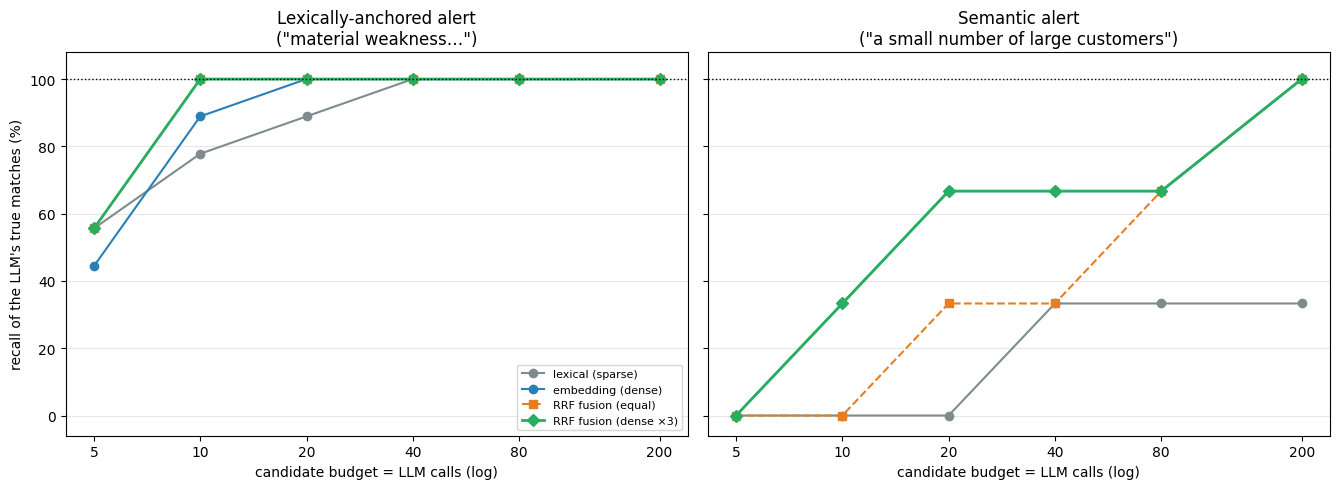

Semantic alert ceilings — lexical 33% vs embedding 100%: the dense arm recovers 67 points the trigram seed can never reach.


In [4]:
def panel(ax, df, title):
    ax.plot(df.budget, df.lexical, "o-", color="#7f8c8d", label="lexical (sparse)")
    ax.plot(df.budget, df.embedding, "o-", color="#2980b9", label="embedding (dense)")
    ax.plot(df.budget, df.rrf_equal, "s--", color="#e67e22", label="RRF fusion (equal)")
    ax.plot(df.budget, df.rrf_embweighted, "D-", color="#27ae60", lw=2, label="RRF fusion (dense ×3)")
    ax.axhline(100, ls=":", color="k", lw=1)
    ax.set_xscale("log"); ax.set_xticks(df.budget); ax.set_xticklabels([int(b) for b in df.budget]); ax.minorticks_off()
    ax.set_ylim(-6, 108); ax.set_xlabel("candidate budget = LLM calls (log)"); ax.set_title(title)
    ax.grid(alpha=.3, axis="y")
fig, ax = plt.subplots(1, 2, figsize=(13.5, 5), sharey=True)
panel(ax[0], df_lex, 'Lexically-anchored alert\n("material weakness…")')
panel(ax[1], df_sem, 'Semantic alert\n("a small number of large customers")')
ax[0].set_ylabel("recall of the LLM's true matches (%)"); ax[0].legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

lex_ceil = df_sem.lexical.max(); emb_ceil = df_sem.embedding.max()
print(f"Semantic alert ceilings — lexical {lex_ceil:.0f}% vs embedding {emb_ceil:.0f}%: "
      f"the dense arm recovers {emb_ceil-lex_ceil:.0f} points the trigram seed can never reach.")


## 4. Finding 1 — the dense arm recovers what lexical can't

On the semantic alert the lexical seed's **ceiling** (the most it can reach at *any* budget) is
only a third of the matches; the dense seed reaches all of them. This is the textbook reason to
add a dense retriever, and it is exactly the limit E3 ran into. The seed *diagnoses its own
boundary*: when lexical recall plateaus well below the LLM's count, you are in semantic
territory and the embedding arm earns its keep.

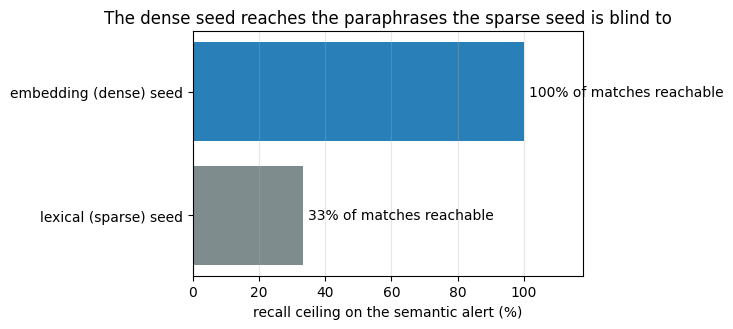

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 3.4))
b = ax.barh(["lexical (sparse) seed","embedding (dense) seed"], [lex_ceil, emb_ceil],
            color=["#7f8c8d","#2980b9"])
for bar,v in zip(b,[lex_ceil,emb_ceil]):
    ax.text(v+1.5, bar.get_y()+bar.get_height()/2, f"{v:.0f}% of matches reachable", va="center", fontsize=10)
ax.set_xlim(0,118); ax.set_xlabel("recall ceiling on the semantic alert (%)")
ax.set_title("The dense seed reaches the paraphrases the sparse seed is blind to")
ax.grid(alpha=.3, axis="x"); plt.tight_layout(); plt.show()


## 5. Findings 2 & 3 — naive fusion can hurt; weighting fixes it

Fusing two retrievers is standard practice, but a subtlety the lab makes visible: **reciprocal-
rank fusion with equal weights can be *worse* than the better arm alone**, because it lets a weak
retriever's high-ranked junk crowd out a strong retriever's hits. On the semantic alert at a tight
budget, equal-RRF sits *below* the embedding arm. Weighting the dense arm (×3) stops the dilution
and tracks the stronger arm — and, crucially, it does **not** hurt the lexically-anchored case,
where both arms are good. One robust default for both regimes.

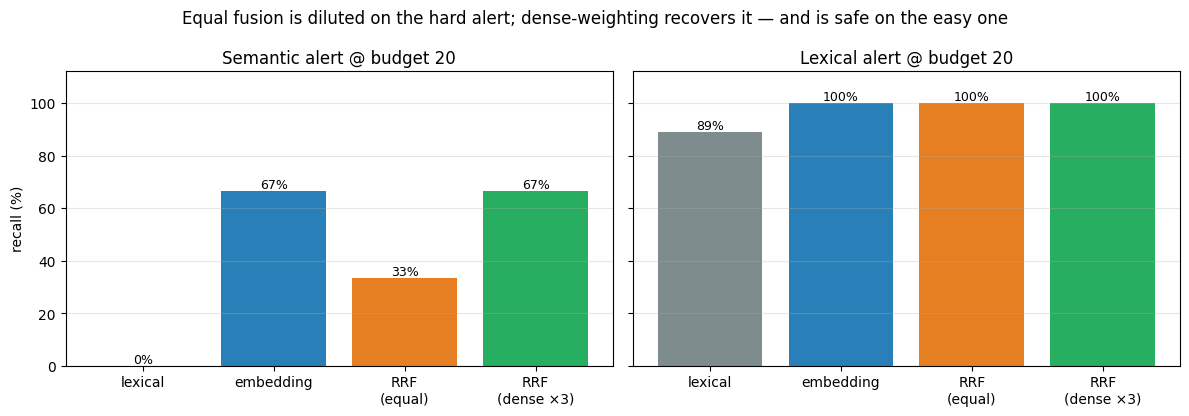

Semantic @ budget 20: equal-RRF 33% vs dense-weighted 67% (embedding alone 67%).  Lexical alert: dense-weighted 100% — no harm done.


In [6]:
b0 = 20
def at(df, bud):
    row = df[df.budget==bud]
    return row.iloc[0] if len(row) else df.iloc[(df.budget-bud).abs().argmin()]
r_sem, r_lex = at(df_sem, b0), at(df_lex, b0)
labels = ["lexical","embedding","RRF\n(equal)","RRF\n(dense ×3)"]
cols = ["#7f8c8d","#2980b9","#e67e22","#27ae60"]
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for a, row, ttl in [(ax[0], r_sem, f'Semantic alert @ budget {b0}'), (ax[1], r_lex, f'Lexical alert @ budget {b0}')]:
    vals = [row.lexical, row.embedding, row.rrf_equal, row.rrf_embweighted]
    bb = a.bar(labels, vals, color=cols)
    for bar,v in zip(bb,vals): a.text(bar.get_x()+bar.get_width()/2, v+1, f"{v:.0f}%", ha="center", fontsize=9)
    a.set_title(ttl); a.set_ylim(0,112); a.grid(alpha=.3, axis="y")
ax[0].set_ylabel("recall (%)")
fig.suptitle("Equal fusion is diluted on the hard alert; dense-weighting recovers it — and is safe on the easy one")
plt.tight_layout(); plt.show()
print(f"Semantic @ budget {b0}: equal-RRF {r_sem.rrf_equal:.0f}% vs dense-weighted {r_sem.rrf_embweighted:.0f}% "
      f"(embedding alone {r_sem.embedding:.0f}%).  Lexical alert: dense-weighted {r_lex.rrf_embweighted:.0f}% — no harm done.")


## 6. The payoff in a search context — coverage per LLM call

The whole point is to spend the expensive reader sparingly. With the dense-weighted hybrid seed,
how much of the LLM's coverage do you get for how many calls (out of 200 exhaustive)? For the
lexically-anchored alert, **full coverage at a small budget** — a multiplicative saving with *no*
loss. For the hard semantic alert, the hybrid is what makes high coverage *reachable at all*
(lexical alone tops out at a third); full coverage of the rare, deeply-paraphrased match costs
more budget — an honest, visible trade rather than a silent miss.

In [7]:
def coverage_at(df, bud): return at(df, bud).rrf_embweighted
N = 200
rows = []
for name, df in [("lexically-anchored", df_lex), ("semantic", df_sem)]:
    for bud in [20, 40]:
        rows.append(dict(alert=name, budget=bud, calls=bud, x_fewer=f"{N/bud:.0f}×",
                         coverage=f"{coverage_at(df, bud):.0f}%"))
econ = pd.DataFrame(rows); display(econ)
print("Read it as: at 5× fewer LLM calls (budget 40), the lexically-anchored alert is fully covered; "
      "the hard semantic alert reaches its dense-arm coverage there too, with the last deeply-"
      "paraphrased match available if you widen the budget — a dial, not a blind spot.")


,alert,budget,calls,x_fewer,coverage
0,lexically-anchored,20,20,10×,100%
1,lexically-anchored,40,40,5×,100%
2,semantic,20,20,10×,67%
3,semantic,40,40,5×,67%


Read it as: at 5× fewer LLM calls (budget 40), the lexically-anchored alert is fully covered; the hard semantic alert reaches its dense-arm coverage there too, with the last deeply-paraphrased match available if you widen the budget — a dial, not a blind spot.


## Honest scope / what E4 establishes

- **It is a RAG stack, deliberately.** Sparse retriever ∪ dense retriever → LLM reader is the
  proven design; using it here is a strength. The contribution is the *framing* — the cost law,
  budget-as-recall-dial, and a seed that reports its own lexical→semantic boundary.
- **The dense arm is not optional for semantic alerts.** Lexical retrieval has a hard ceiling on
  paraphrased intent (here, a third of the matches). Embeddings cross it.
- **Fusion needs a thumb on the scale.** Equal-weight RRF can dilute a dominant arm; weighting the
  dense arm (×3) is the robust default across both regimes. ("Always blend" → "always blend, but
  weight the dense arm.")
- **Cost is paid once.** A decoder LLM cannot serve good embeddings, so the dense seed uses a
  separate small embedding model — but the corpus is embedded a single time and cached, and the
  LLM labels are cached too, so this notebook re-renders without any inference.
- **Coverage vs calls is a dial, not a guarantee.** For well-anchored alerts you get full coverage
  at a large saving; for deeply paraphrased ones the hybrid makes full coverage *reachable* and
  lets you choose where on the speed↔coverage curve to sit — explicitly.

## Next — into COBOLMM

The whole stack is now validated to drop into COBOLMM as a menu item: an analyst types an alert
phrase; the **dense-weighted hybrid seed** runs over the already-indexed SEC / RSS / transcript
corpora; the configured local model (from `mm_config`, with `num_ctx`) judges only the shortlist;
a **budget knob** sets the speed↔coverage trade. An overnight, corpus-wide LLM sweep becomes a
coffee-break query — with the coverage dial in the analyst's hand.